# Exploratory Data Analysis of Ozone (O3) (2020–2023)
This notebook explores temporal trends, seasonal behavior, city-wise variation, and statistical characteristics of ground-level O3 concentrations across Canadian cities.
Objective:
- Understand O3 distribution
- Identify seasonal patterns
- Compare cities
- Prepare insights for PM2.5 relationship and modeling

## Importing Required Libraries and Loading Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../../data/master/O3_2020 cleaned Master_20_23.csv")
df.head()

,City,Date,O3,Year,Month,Season
0,St. John's,2020-01-01,32.625,2020,1,Winter
1,St. John's,2020-01-02,27.91666667,2020,1,Winter
2,St. John's,2020-01-03,32.16666667,2020,1,Winter
3,St. John's,2020-01-04,23.45833333,2020,1,Winter
4,St. John's,2020-01-05,19.20833333,2020,1,Winter


## Dataset Overview and Data Quality Checks

In [6]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
# O3 might be object like PM25 was → convert to numeric
df["O3"] = pd.to_numeric(df["O3"], errors="coerce")
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338222 entries, 0 to 338221
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   City    338222 non-null  object        
 1   Date    338222 non-null  datetime64[ns]
 2   O3      327124 non-null  float64       
 3   Year    338222 non-null  int64         
 4   Month   338222 non-null  int64         
 5   Season  338222 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 15.5+ MB


,Date,O3,Year,Month
count,338222,327124.000000,338222.000000,338222.000000
mean,2021-12-31 09:25:39.554494208,25.880284,2021.500050,6.522923
min,2020-01-01 00:00:00,0.000000,2020.000000,1.000000
25%,2020-12-30 00:00:00,19.333333,2020.000000,4.000000
50%,2021-12-31 00:00:00,25.875000,2021.000000,7.000000
75%,2023-01-03 00:00:00,32.521739,2023.000000,10.000000
max,2023-12-31 00:00:00,69.000000,2023.000000,12.000000
std,NaN,9.361320,1.120271,3.448710


## Distribution of O3 Concentrations
We examine the spread and skewness of O3 values to understand typical levels and extreme events.

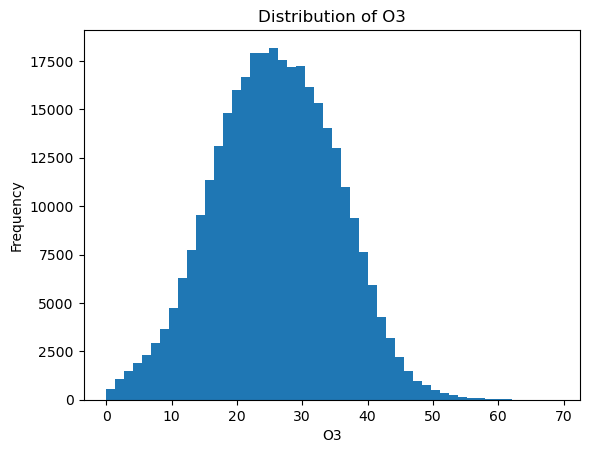

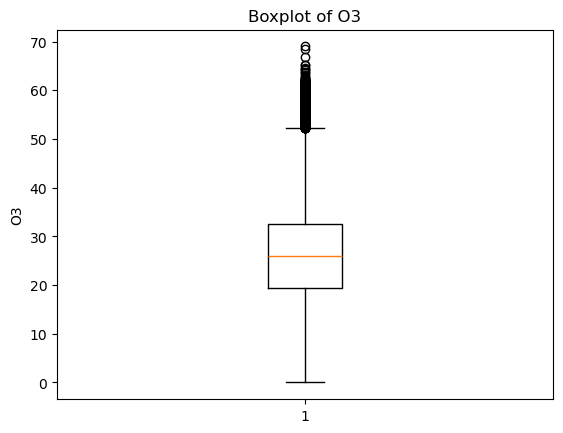

0.0010693078440609796

In [9]:
o3 = df["O3"].dropna()
plt.figure()
plt.hist(o3, bins=50)
plt.title("Distribution of O3")
plt.xlabel("O3")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(o3, vert=True)
plt.title("Boxplot of O3")
plt.ylabel("O3")
plt.show()
o3.skew()

## Zoomed View (99th Percentile)
Because environmental data can contain extreme values, we also visualize a zoomed distribution to better interpret typical behavior.

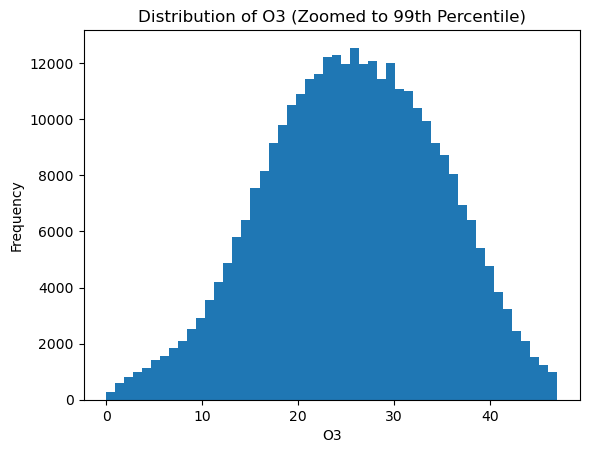

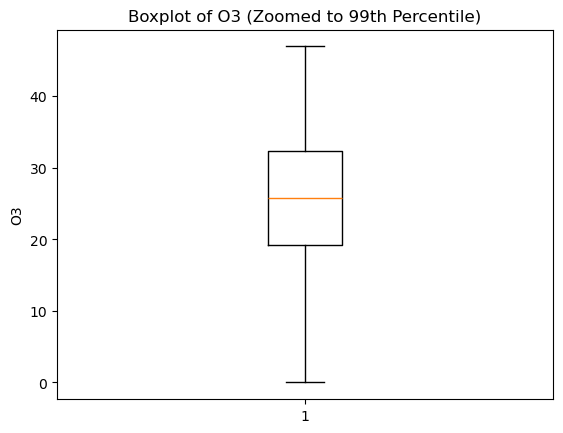

In [12]:
p99 = o3.quantile(0.99)
plt.figure()
plt.hist(o3[o3 <= p99], bins=50)
plt.title("Distribution of O3 (Zoomed to 99th Percentile)")
plt.xlabel("O3")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(o3[o3 <= p99])
plt.title("Boxplot of O3 (Zoomed to 99th Percentile)")
plt.ylabel("O3")
plt.show()

### Interpretation
The distribution of O3 concentrations appears approximately symmetric and bell-shaped,
indicating relatively stable atmospheric behavior compared to PM2.5.
Unlike PM2.5, O3 does not exhibit extreme right-skewness, suggesting fewer episodic spikes.

## Year-wise Trend of O3 (2020–2023)
This analysis checks whether ozone levels increased, decreased, or remained stable across years.

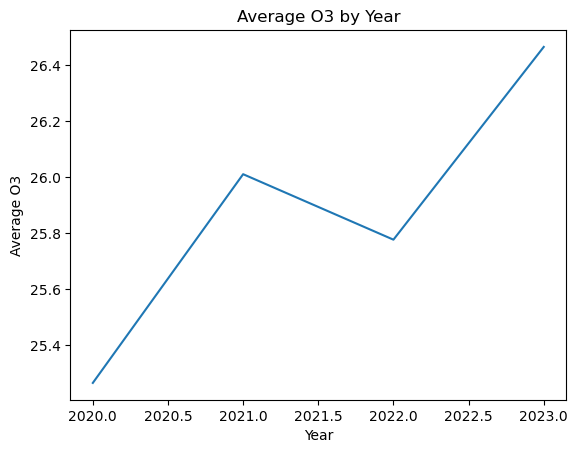

Year
2020    25.266121
2021    26.011503
2022    25.777668
2023    26.465995
Name: O3, dtype: float64

In [15]:
df["Year"] = df["Date"].dt.year
yearly_avg = df.groupby("Year")["O3"].mean()
plt.figure()
plt.plot(yearly_avg.index, yearly_avg.values)
plt.title("Average O3 by Year")
plt.xlabel("Year")
plt.ylabel("Average O3")
plt.show()
yearly_avg

### Interpretation
O3 levels show a relatively stable trend from 2020–2023, with only minor fluctuations.
Unlike PM2.5, ozone did not experience a dramatic spike in 2023.
This suggests that wildfire events have a stronger influence on particulate matter than on ozone levels.

## Monthly Average O3
Monthly trends help identify recurring seasonal behavior across the calendar year.

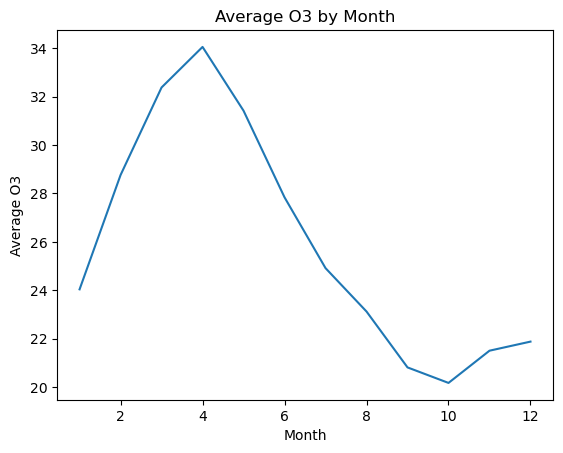

In [18]:
df["Month"] = df["Date"].dt.month
monthly_avg = df.groupby("Month")["O3"].mean()
plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)
plt.title("Average O3 by Month")
plt.xlabel("Month")
plt.ylabel("Average O3")
plt.show()

### Interpretation
O3 concentrations peak during spring and early summer months,
consistent with photochemical ozone formation driven by sunlight intensity.
Levels decline during fall and winter when solar radiation is reduced.

## Seasonal Variation in O3

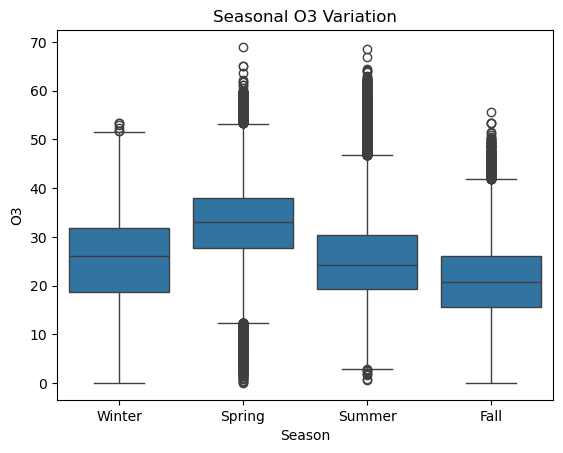

In [22]:
plt.figure()
sns.boxplot(x="Season", y="O3", data=df)
plt.title("Seasonal O3 Variation")
plt.show()

### Interpretation
Seasonal analysis confirms that O3 levels are highest during spring,
followed by summer. Fall exhibits the lowest concentrations.
This pattern aligns with ozone's photochemical formation mechanism.

## City-wise Average O3 Levels
We identify cities with the highest average O3 concentrations.

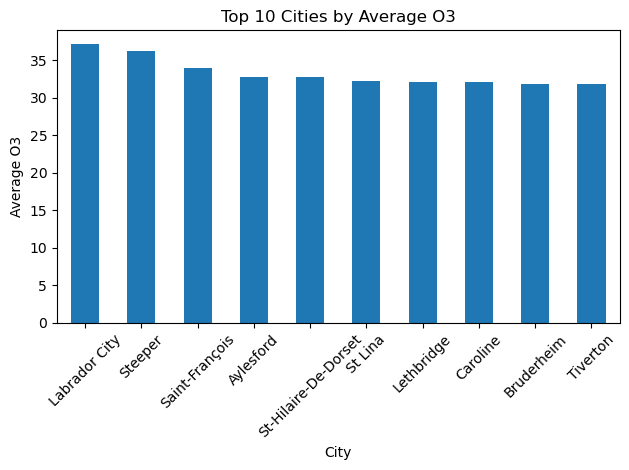

City
Labrador City           37.136500
Steeper                 36.273868
Saint-François          34.022325
Aylesford               32.786948
St-Hilaire-De-Dorset    32.712443
St Lina                 32.256189
Lethbridge              32.128154
Caroline                32.067024
Bruderheim              31.899080
Tiverton                31.786859
Name: O3, dtype: float64

In [25]:
city_avg = df.groupby("City")["O3"].mean().sort_values(ascending=False)
top10 = city_avg.head(10)

plt.figure()
top10.plot(kind="bar")
plt.title("Top 10 Cities by Average O3")
plt.ylabel("Average O3")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
top10

### Interpretation
The cities with highest O3 levels differ from those with highest PM2.5 levels,
suggesting that ozone formation mechanisms differ from particulate pollution sources.
This indicates spatial variability in pollutant dynamics.

## O3 Trends for Top 5 Cities
We track how ozone levels changed over time in the cities with highest average O3.

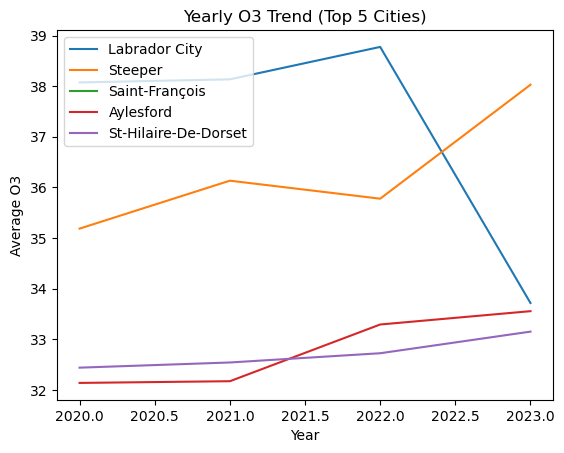

In [28]:
top5_cities = city_avg.head(5).index

plt.figure()
for city in top5_cities:
    city_data = df[df["City"] == city]
    yearly = city_data.groupby("Year")["O3"].mean()
    plt.plot(yearly.index, yearly.values, label=city)

plt.legend()
plt.title("Yearly O3 Trend (Top 5 Cities)")
plt.xlabel("Year")
plt.ylabel("Average O3")
plt.show()